# Visualización de resultados

## Equipo 74  
* Diana Jimena López Nájera
* Marcelo Ismael López Verdugo
* Salma Alejandra Macías Rosas
* Dario Maximiliano Mendoza Orozco

In [29]:
from pyspark.sql import SparkSession
from pyspark.sql.functions import col, count, sum, avg, when, isnan, lit, desc, hour, dayofmonth, dayofweek, min, max
from pyspark.sql.functions import split, regexp_extract
from pyspark.sql.functions import collect_set, countDistinct, collect_list
from pyspark.sql.types import DoubleType, FloatType
from pyspark.ml import Pipeline
from pyspark.ml.feature import VectorAssembler, StringIndexer
from pyspark.ml.regression import DecisionTreeRegressor, GBTRegressor
from pyspark.ml.evaluation import MulticlassClassificationEvaluator, RegressionEvaluator




spark = SparkSession.builder \
    .appName("Analisis Ecommerce Octubre") \
    .config("spark.driver.memory", "6g") \
    .getOrCreate()

spark

## Directorio del dataset

In [21]:
root=".."
file_path = root + "/datasets/2019-Oct.csv"

df = spark.read.option("header", True) \
               .option("inferSchema", True) \
               .csv(file_path)

df.show(5, truncate=False)

+-------------------+----------+----------+-------------------+-----------------------------------+--------+-------+---------+------------------------------------+
|event_time         |event_type|product_id|category_id        |category_code                      |brand   |price  |user_id  |user_session                        |
+-------------------+----------+----------+-------------------+-----------------------------------+--------+-------+---------+------------------------------------+
|2019-09-30 17:00:00|view      |44600062  |2103807459595387724|NULL                               |shiseido|35.79  |541312140|72d76fde-8bb3-4e00-8c23-a032dfed738c|
|2019-09-30 17:00:00|view      |3900821   |2053013552326770905|appliances.environment.water_heater|aqua    |33.2   |554748717|9333dfbd-b87a-4708-9857-6336556b0fcc|
|2019-09-30 17:00:01|view      |17200506  |2053013559792632471|furniture.living_room.sofa         |NULL    |543.1  |519107250|566511c2-e2e3-422b-b695-cf8e6e792ca8|
|2019-09-30 17:0

In [22]:
df.printSchema()

root
 |-- event_time: timestamp (nullable = true)
 |-- event_type: string (nullable = true)
 |-- product_id: integer (nullable = true)
 |-- category_id: long (nullable = true)
 |-- category_code: string (nullable = true)
 |-- brand: string (nullable = true)
 |-- price: double (nullable = true)
 |-- user_id: integer (nullable = true)
 |-- user_session: string (nullable = true)



# Instrucciones  
1.    Definir un proceso de validación cruzada para medir la variabilidad de los resultados a partir del algoritmo o algoritmos que mejor resultado reportaron en la Actividad 4 del Módulo 5. Para ello y partiendo de la muestra M = {Mi: Mi es una partición derivada de las variables de caracterización de la población} construida en el paso 1 de la actividad 4 del Módulo 5, se debe de determinar un valor “k” para el proceso de validación cruzada “k-fold” a implementar. Este valor deberá de ser argumentado con profundidad, de tal forma que se garantice que cada uno de los “k-fold” generados, sean muestras representativas de la población. Incluir una sección en el Jupyter Notebook que construyes dónde se explique este paso.
2.    Construcción de los “k-folds” definidos en el paso 1. Para poblar cada uno de los “k-fold”, tomar en cuenta el proceso de muestreo que se propuso desde la Actividad 3 del Módulo 4. Tomar en cuenta que eventualmente el volumen de datos es alto (Big Data), por lo que, entre más pliegues generados, la experimentación será más costosa. Crear una sección en el Jupyter Notebook que generas, en el cual se implemente la construcción de cada uno de los folds, documentando el código correspondiente.
3.    Fase de entrenamiento. Para esta etapa y generando los conjuntos de entrenamiento y prueba que se pueden construir a partir de los “k-folds” generados en la etapa previa, realizar el proceso de entrenamiento a partir del algoritmo que mejor reportó resultados en la Actividad 4 del Módulo 5. Realizar la etapa de entrenamiento y registrar los resultados necesarios y suficientes para obtener el modelo que mejor generaliza los patrones que se aprenden de cada experimento realizado. La medición de calidad de resultado será a partir de las métricas que se establecieron como las mejores identificadas en la actividad 4 del Módulo 5. La experimentación se llevará a cabo a partir de la biblioteca PySpark, implementando el código correspondiente en una sección de tu Jupyter Notebook que construyes, el cual titularás “Experimentacion”
4.    Visualización de resultados. A partir de la elección de diferentes bibliotecas para la visualización de resultados, se deberán de mostrar gráficas que te permitan visualizar los resultados de la etapa de entrenamiento del paso previo (resultados de cada Fold a partir de las métricas usadas para medir dichos resultados, evolución de las etapas de entrenamiento para detectar sobre-ajuste, estadísticas generales para medir la variabilidad de los resultados obtenidos, entre otras que juzgues pertinentes). Crear una sección en tu Jupyter Notebook titulada “Resultados”, donde se muestre y argumente los resultados que has obtenido en esta etapa de experimentación.
5.    Discusión de resultados y Conclusiones. En esta última sección, deberás de realizar un análisis de los resultados obtenidos de acuerdo a la tarea de aprendizaje que te has planteado en tu proyecto, de tal forma que se analice que tan significativos son los resultados obtenidos, la variabilidad que se obtuvo en los experimentos, para poder determinar qué tan significativos son estos resultados de acuerdo a la tarea de aprendizaje plantada. Lo anterior deberás de plasmarlo en una sección de tu Jupyter Notebook con título “Discusión y conclusiones”.

# Depuración y preparación

## Análisis de cardinalidad
Es útil conocer cuantos valores únicos existen por columna para identificar potenciales particionamientos

In [23]:
df_clean = df.dropna()
df_clean = df_clean.withColumn("weekhour", dayofweek(col("event_time")) + hour(col("event_time")) / 24)

non_numeric_columns = [name for name, dtype in df_clean.dtypes if dtype == "string"]
for col_name in non_numeric_columns:
    distinct_count = df_clean.select(col_name).distinct().count()
    print(f"{col_name}: dtype=string, distinct={distinct_count}")

    top_values = [row[col_name] for row in df_clean.groupBy(col_name)
                                              .count()
                                              .orderBy(desc("count"))
                                              .limit(10)
                                              .select(col_name)
                                              .collect()]

    grouped_col = f"{col_name}_grouped"
    df_clean = df_clean.withColumn(
        grouped_col,
        when(col(col_name).isin(top_values), col(col_name)).otherwise(lit("other"))
    )

print("Columnas agrupadas creadas:", [f"{c}_grouped" for c in non_numeric_columns])

df_clean.describe().show()

event_type: dtype=string, distinct=3
category_code: dtype=string, distinct=126
brand: dtype=string, distinct=1731
user_session: dtype=string, distinct=6419693
Columnas agrupadas creadas: ['event_type_grouped', 'category_code_grouped', 'brand_grouped', 'user_session_grouped']
+-------+----------+-----------------+--------------------+-------------------+--------+-----------------+--------------------+--------------------+------------------+------------------+---------------------+-------------+--------------------+
|summary|event_type|       product_id|         category_id|      category_code|   brand|            price|             user_id|        user_session|          weekhour|event_type_grouped|category_code_grouped|brand_grouped|user_session_grouped|
+-------+----------+-----------------+--------------------+-------------------+--------+-----------------+--------------------+--------------------+------------------+------------------+---------------------+-------------+--------------

In [24]:
#Valores únicos por variable
columns_to_check = ["product_id", "category_id", "category_code", "brand", "user_id", "user_session"]

for c in columns_to_check:
    print(f"{c}: {df.select(c).distinct().count():,} valores únicos")

product_id: 166,794 valores únicos
category_id: 624 valores únicos
category_code: 127 valores únicos
brand: 3,446 valores únicos
user_id: 3,022,290 valores únicos
user_session: 9,244,422 valores únicos


# Uso de clusters para generación de categorías de usuario  
## "Entrenamiento no supervisado"  
En cuanto a generar recomendaciones para usuarios es posible hacer un sistema de recomendaciones a partir de matrices dispersas.  Se almacena una categorización de acuerdo a tales clusters de usuario convirtiendo la gran cantidad de usuarios en solo un tipo o categoría.  A partir de tal categorías se pueden generar proyecciones de ventas o sugerencias para anuncios

In [25]:
## Clustering de clientes por usuario
# Agrupamos por user_id y calculamos métricas de interacción y precio.
user_features = (
    df_clean
    .groupBy("user_id")
    .agg(
        count("*").alias("interactions"),
        sum("price").alias("total_spend"),
        avg("price").alias("avg_price"),
        countDistinct("brand").alias("brand_diversity"),
        collect_list("brand").alias("brand_list")
    )
)

user_features.show(10, truncate=False)

# Vectorizamos las marcas con sparse features usando CountVectorizer.
from pyspark.ml.feature import CountVectorizer, StandardScaler
from pyspark.ml.clustering import KMeans

cv = CountVectorizer(inputCol="brand_list", outputCol="brand_vec", vocabSize=100, minDF=2.0)
assembler = VectorAssembler(
    inputCols=["interactions", "total_spend", "avg_price", "brand_diversity", "brand_vec"],
    outputCol="raw_features"
)
scaler = StandardScaler(inputCol="raw_features", outputCol="features", withMean=True, withStd=True)

pipeline = Pipeline(stages=[cv, assembler, scaler])
pipeline_model = pipeline.fit(user_features)
user_vector = pipeline_model.transform(user_features)

# Entrenamos KMeans y asignamos un segmento de cliente.
k = 4
kmeans = KMeans(k=k, featuresCol="features", predictionCol="customer_segment", seed=42)
kmeans_model = kmeans.fit(user_vector)
clustered_users = kmeans_model.transform(user_vector)

clustered_users.select(
    "user_id", "customer_segment", "interactions", "total_spend", "avg_price", "brand_diversity"
).show(20, truncate=False)

# Agregamos la categoría al dataset original para análisis posterior.
df_with_segment = df_clean.join(
    clustered_users.select("user_id", "customer_segment"),
    on="user_id",
    how="left"
)

print("Distribución de segmentos de cliente:")
df_with_segment.groupBy("customer_segment").count().orderBy("customer_segment").show()

# Opcional: ver centros de los clústeres.
print("Centros de cluster:")
for idx, center in enumerate(kmeans_model.clusterCenters()):
    print(f"Cluster {idx}: {center}")


+---------+------------+------------------+------------------+---------------+--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------+
|user_id  |interactions|total_spend       |avg_price         |brand_diversity|brand_list                                                                                                                                                                                                                                        |
+---------+------------+------------------+------------------+---------------+--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------+
|240522111|34          |7215.24000

# Visualización de clusters

In [26]:
# Reducción de dimensionalidad con PCA para visualización 2D
from pyspark.ml.feature import PCA
import pandas as pd
import matplotlib.pyplot as plt

# Aplicar PCA a 2 componentes para visualizar
pca = PCA(k=2, inputCol="features", outputCol="pca_features")
pca_model = pca.fit(user_vector)
user_pca = pca_model.transform(user_vector)

# Unir clustered_users con user_pca para recuperar customer_segment
user_pca_with_segment = user_pca.join(
    clustered_users.select("user_id", "customer_segment"),
    on="user_id",
    how="left"
)

# Extraer componentes PCA y segmentos para visualización
viz_data = user_pca_with_segment.select(
    "user_id", "customer_segment", "interactions", "total_spend", "pca_features"
).collect()

# Convertir a pandas para visualización
pca_list = []
for row in viz_data:
    pca_list.append({
        "user_id": row["user_id"],
        "segment": row["customer_segment"],
        "interactions": row["interactions"],
        "total_spend": row["total_spend"],
        "PCA1": float(row["pca_features"][0]),
        "PCA2": float(row["pca_features"][1])
    })

if not pca_list:
    print("No hay datos para visualizar.")
else:
    df_viz = pd.DataFrame(pca_list)

    # Calcular tamaños de puntos basados en interacciones
    interactions = df_viz["interactions"].astype(float)
    size_min, size_max = 20, 200
    sizes = size_min + (interactions - interactions.min()) / (interactions.max() - interactions.min() + 1e-9) * (size_max - size_min)

    fig, ax = plt.subplots(figsize=(10, 7))
    for segment in sorted(df_viz["segment"].unique()):
        subset = df_viz[df_viz["segment"] == segment]
        ax.scatter(
            subset["PCA1"],
            subset["PCA2"],
            s=sizes[subset.index],
            alpha=0.7,
            label=f"Segmento {segment}"
        )

    ax.set_title("Segmentación de clientes por clusters (PCA 2D)")
    ax.set_xlabel("PCA1")
    ax.set_ylabel("PCA2")
    ax.legend(title="Segmento", bbox_to_anchor=(1.05, 1), loc="upper left")
    ax.grid(True, linestyle='--', alpha=0.4)
    plt.tight_layout()
    plt.show()

    print(f"Total de usuarios visualizados: {len(df_viz)}")


Py4JJavaError: An error occurred while calling o1500.collectToPython.
: org.apache.spark.SparkException: Job aborted due to stage failure: Task 11 in stage 685.0 failed 1 times, most recent failure: Lost task 11.0 in stage 685.0 (TID 6171) (WGC1HM7P656F3.Hermosillo.ford.com executor driver): TaskResultLost (result lost from block manager)
Driver stacktrace:
	at org.apache.spark.scheduler.DAGScheduler.$anonfun$abortStage$3(DAGScheduler.scala:3122)
	at scala.Option.getOrElse(Option.scala:201)
	at org.apache.spark.scheduler.DAGScheduler.$anonfun$abortStage$2(DAGScheduler.scala:3122)
	at org.apache.spark.scheduler.DAGScheduler.$anonfun$abortStage$2$adapted(DAGScheduler.scala:3114)
	at scala.collection.immutable.List.foreach(List.scala:323)
	at org.apache.spark.scheduler.DAGScheduler.abortStage(DAGScheduler.scala:3114)
	at org.apache.spark.scheduler.DAGScheduler.$anonfun$handleTaskSetFailed$1(DAGScheduler.scala:1303)
	at org.apache.spark.scheduler.DAGScheduler.$anonfun$handleTaskSet

Estadísticas por segmento de cliente:
+----------------+---------+-----------------+------------------+------------------+-------------------+
|customer_segment|num_users|avg_interactions |avg_total_spend   |avg_price         |avg_brand_diversity|
+----------------+---------+-----------------+------------------+------------------+-------------------+
|0               |2234983  |8.046203483426943|2868.758987826692 |373.70122496606   |2.474888175883217  |
|1               |11191    |88.86909123402734|15547.409101956931|148.84443124722176|15.322133857564115 |
|2               |66637    |100.5682878881102|38431.87893992829 |387.9790187016921 |12.977504989720426 |
|3               |10225    |86.19941320293398|22055.71915207824 |246.6399187725648 |13.454278728606356 |
+----------------+---------+-----------------+------------------+------------------+-------------------+



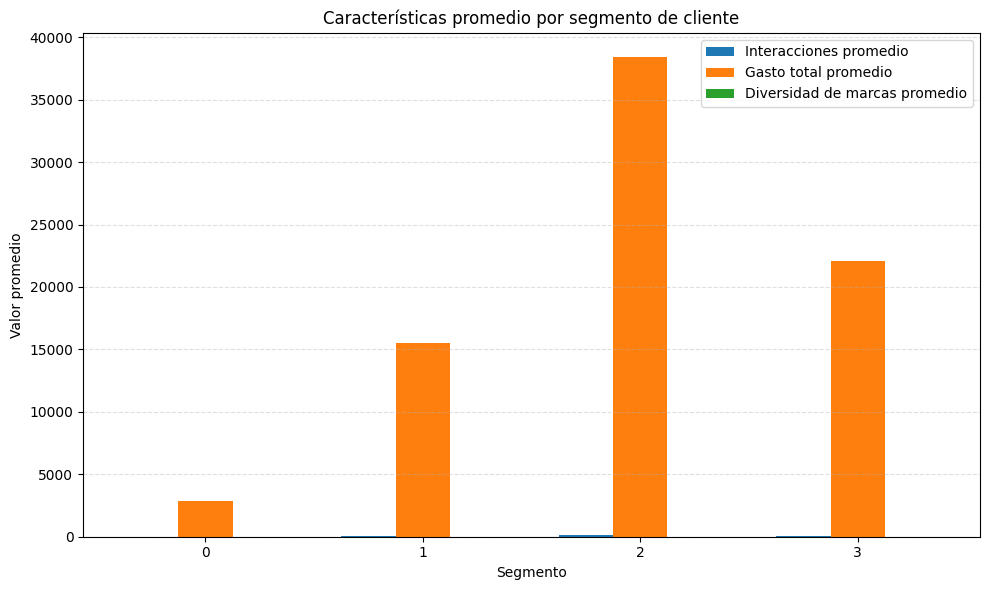

In [28]:
# Análisis de características por cluster
cluster_stats = (
    clustered_users
    .groupBy("customer_segment")
    .agg(
        count("*").alias("num_users"),
        avg("interactions").alias("avg_interactions"),
        avg("total_spend").alias("avg_total_spend"),
        avg("avg_price").alias("avg_price"),
        avg("brand_diversity").alias("avg_brand_diversity")
    )
    .orderBy("customer_segment")
)

print("Estadísticas por segmento de cliente:")
cluster_stats.show(truncate=False)

# Visualizar estadísticas por cluster
stats_df = cluster_stats.toPandas()

# Gráfico de barras con matplotlib
fig2, ax2 = plt.subplots(figsize=(10, 6))
bar_width = 0.25
indices = range(len(stats_df))

ax2.bar([i - bar_width for i in indices], stats_df["avg_interactions"], width=bar_width, label="Interacciones promedio")
ax2.bar(indices, stats_df["avg_total_spend"], width=bar_width, label="Gasto total promedio")
ax2.bar([i + bar_width for i in indices], stats_df["avg_brand_diversity"], width=bar_width, label="Diversidad de marcas promedio")

ax2.set_xticks(indices)
ax2.set_xticklabels(stats_df["customer_segment"].astype(str))
ax2.set_xlabel("Segmento")
ax2.set_ylabel("Valor promedio")
ax2.set_title("Características promedio por segmento de cliente")
ax2.legend()
ax2.grid(axis="y", linestyle="--", alpha=0.4)
plt.tight_layout()
plt.show()


# EDA  
Por la gran cantidad de valores únicos se hace un análisis exploratorio en el pareto para visualizar cuánto porcentaje de los valores se pueden agarrar en, por decirlo, un Top 10.

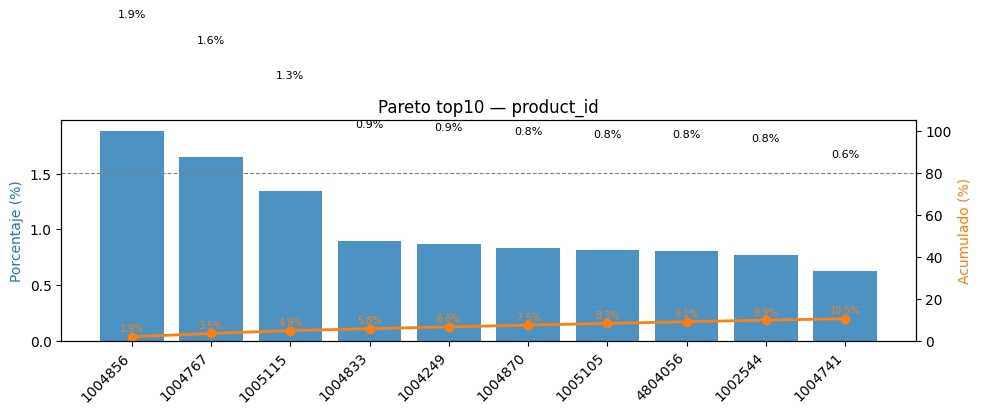

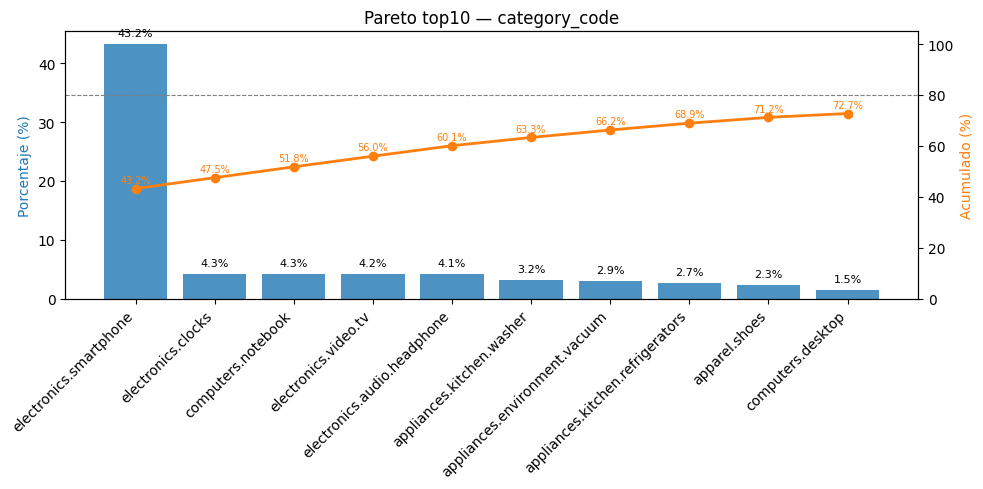

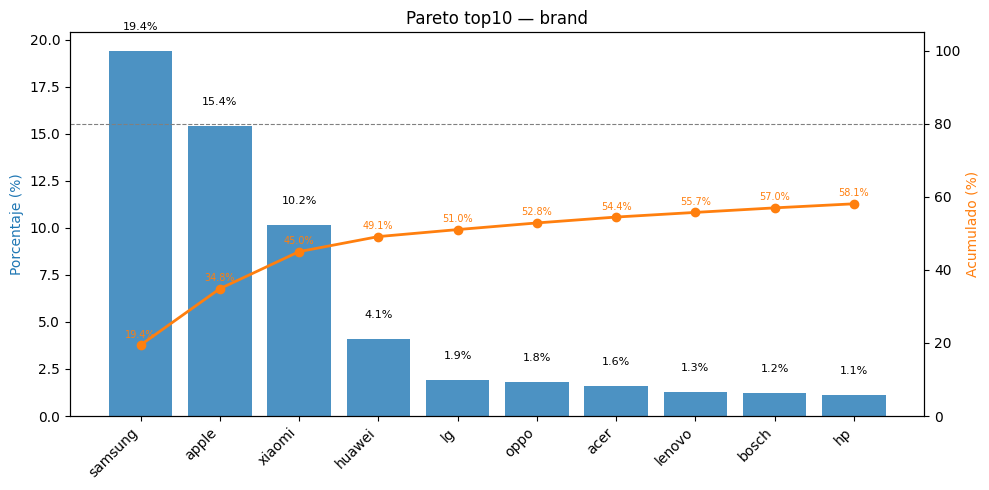

In [ ]:
# Histogramas y Pareto (top 10) por columna
import matplotlib.pyplot as plt
import numpy as np


columns_to_check = ["product_id", "category_code", "brand"]
# Selección de columnas: usa `columns_to_check` si existe, sino toma columnas no numéricas
try:
    cols = columns_to_check
except NameError:
    # tomar columnas con cardinalidad razonable
    cols = [c for c, t in df_clean.dtypes]

for col_name in cols:
    # contar total de filas (para porcentajes)
    total = df_clean.count()

    # obtener top 10 valores y sus cuentas
    top_df = (
        df_clean
        .groupBy(col_name)
        .count()
        .orderBy(desc("count"))
        .limit(10)
    )

    # convertir a pandas (pequeño: máximo 10 filas)
    pdf = top_df.toPandas()
    if pdf.empty:
        print(f"{col_name}: sin datos para mostrar (vacío)")
        continue

    pdf = pdf.rename(columns={col_name: 'value'})
    pdf['percent'] = pdf['count'] / float(total) * 100.0
    pdf['cumulative'] = pdf['percent'].cumsum()

    # configuración del gráfico
    fig, ax = plt.subplots(figsize=(10, 5))
    indices = np.arange(len(pdf))

    # barras: porcentaje por valor
    bars = ax.bar(indices, pdf['percent'], color='C0', alpha=0.8)
    ax.set_ylabel('Porcentaje (%)', color='C0')
    ax.set_xticks(indices)
    ax.set_xticklabels(pdf['value'].astype(str), rotation=45, ha='right')

    # línea acumulada
    ax2 = ax.twinx()
    ax2.plot(indices, pdf['cumulative'], color='C1', marker='o', linewidth=2)
    ax2.set_ylabel('Acumulado (%)', color='C1')
    ax2.set_ylim(0, 105)

    # anotar porcentajes sobre barras
    for i, (p, c) in enumerate(zip(pdf['percent'], pdf['cumulative'])):
        ax.text(i, p + 1.0, f"{p:.1f}%", ha='center', va='bottom', fontsize=8)
        ax2.text(i, c + 1.5, f"{c:.1f}%", ha='center', va='bottom', fontsize=7, color='C1')

    # línea de referencia 80%
    ax2.axhline(80, color='gray', linestyle='--', linewidth=0.8)

    ax.set_title(f'Pareto top10 — {col_name}')
    plt.tight_layout()
    plt.show()


# Análisis de precios por tipo de evento

In [ ]:
# Análisis de precios por tipo de evento
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Obtener datos de precio por event_type
price_by_event = df_clean.select("event_type", "price").toPandas()

# Crear figura con dos subgráficos
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Gráfico 1: Box plot de precios por tipo de evento
sns.boxplot(data=price_by_event, x="event_type", y="price", ax=axes[0])
axes[0].set_title("Distribución de precios por tipo de evento")
axes[0].set_xlabel("Tipo de evento")
axes[0].set_ylabel("Precio")

# Gráfico 2: Violin plot para mejor visualización de la distribución
sns.violinplot(data=price_by_event, x="event_type", y="price", ax=axes[1])
axes[1].set_title("Densidad de precios por tipo de evento")
axes[1].set_xlabel("Tipo de evento")
axes[1].set_ylabel("Precio")

plt.tight_layout()
plt.show()

# Estadísticas descriptivas por tipo de evento
print("Estadísticas de precio por tipo de evento:")
event_stats = df_clean.groupBy("event_type").agg(
    count("*").alias("count"),
    avg("price").alias("avg_price"),
    min("price").alias("min_price"),
    max("price").alias("max_price")
).orderBy("event_type")
event_stats.show(truncate=False)

Py4JJavaError: An error occurred while calling o897.collectToPython.
: org.apache.spark.SparkException: Job aborted due to stage failure: Task 5 in stage 409.0 failed 1 times, most recent failure: Lost task 5.0 in stage 409.0 (TID 3801) (WGC1HM7P656F3.Hermosillo.ford.com executor driver): TaskResultLost (result lost from block manager)
Driver stacktrace:
	at org.apache.spark.scheduler.DAGScheduler.$anonfun$abortStage$3(DAGScheduler.scala:3122)
	at scala.Option.getOrElse(Option.scala:201)
	at org.apache.spark.scheduler.DAGScheduler.$anonfun$abortStage$2(DAGScheduler.scala:3122)
	at org.apache.spark.scheduler.DAGScheduler.$anonfun$abortStage$2$adapted(DAGScheduler.scala:3114)
	at scala.collection.immutable.List.foreach(List.scala:323)
	at org.apache.spark.scheduler.DAGScheduler.abortStage(DAGScheduler.scala:3114)
	at org.apache.spark.scheduler.DAGScheduler.$anonfun$handleTaskSetFailed$1(DAGScheduler.scala:1303)
	at org.apache.spark.scheduler.DAGScheduler.$anonfun$handleTaskSetFai

# Análisis de precios por evento - Versión PySpark

In [27]:
# Análisis de precios por tipo de evento - Procesamiento 100% PySpark
from pyspark.sql.functions import percentile_approx, stddev, variance, collect_list

# Estadísticas completas por event_type usando PySpark
price_stats = (
    df_clean
    .groupBy("event_type")
    .agg(
        count("*").alias("count"),
        avg("price").alias("mean_price"),
        min("price").alias("min_price"),
        max("price").alias("max_price"),
        stddev("price").alias("stddev_price"),
        variance("price").alias("variance_price"),
        percentile_approx("price", 0.25).alias("q1_price"),
        percentile_approx("price", 0.50).alias("median_price"),
        percentile_approx("price", 0.75).alias("q3_price")
    )
    .orderBy("event_type")
)

print("Estadísticas detalladas por tipo de evento (PySpark):")
price_stats.show(truncate=False)

# Convertir a pandas solo para visualización
stats_df = price_stats.toPandas()

# Visualizar
import matplotlib.pyplot as plt
import pandas as pd

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Gráfico 1: Promedio y mediana
ax1 = axes[0, 0]
x = range(len(stats_df))
ax1.bar([i - 0.2 for i in x], stats_df["mean_price"], width=0.4, label="Media", alpha=0.8)
ax1.bar([i + 0.2 for i in x], stats_df["median_price"], width=0.4, label="Mediana", alpha=0.8)
ax1.set_xticks(x)
ax1.set_xticklabels(stats_df["event_type"])
ax1.set_ylabel("Precio")
ax1.set_title("Media vs Mediana por tipo de evento")
ax1.legend()
ax1.grid(axis="y", alpha=0.3)

# Gráfico 2: Rango intercuartil (IQR)
ax2 = axes[0, 1]
ax2.bar(x, stats_df["q3_price"] - stats_df["q1_price"], 
        bottom=stats_df["q1_price"], label="IQR", alpha=0.8)
ax2.scatter(x, stats_df["median_price"], color='red', s=100, marker='D', label="Mediana", zorder=5)
ax2.set_xticks(x)
ax2.set_xticklabels(stats_df["event_type"])
ax2.set_ylabel("Precio")
ax2.set_title("Rango Intercuartil (IQR) por tipo de evento")
ax2.legend()
ax2.grid(axis="y", alpha=0.3)

# Gráfico 3: Desviación estándar
ax3 = axes[1, 0]
ax3.bar(x, stats_df["stddev_price"], color='coral', alpha=0.8)
ax3.set_xticks(x)
ax3.set_xticklabels(stats_df["event_type"])
ax3.set_ylabel("Desviación Estándar")
ax3.set_title("Variabilidad de precios por tipo de evento")
ax3.grid(axis="y", alpha=0.3)

# Gráfico 4: Distribución de frecuencias
ax4 = axes[1, 1]
ax4.bar(x, stats_df["count"], color='steelblue', alpha=0.8)
ax4.set_xticks(x)
ax4.set_xticklabels(stats_df["event_type"])
ax4.set_ylabel("Cantidad de eventos")
ax4.set_title("Cantidad de eventos por tipo")
ax4.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

# Resumen de variabilidad
print("\nResumen de variabilidad de precios:")
summary = stats_df[["event_type", "mean_price", "median_price", "stddev_price", "count"]].copy()
summary["coefficient_variation"] = (summary["stddev_price"] / summary["mean_price"] * 100).round(2)
print(summary.to_string(index=False))

AttributeError: 'str' object has no attribute 'alias'